In [1]:
import pandas as pd
import numpy as np
df = pd.read_csv("../data/raw/tweets_ai.csv")
df.shape

(893076, 19)

#### Conversión de ids de float a int y a string

In [2]:
df["id"] = df["id"].astype("int64").astype("string")
df["conversation_id"] = df["conversation_id"].astype("int64").astype("string")

#### Conversión de fechas a datetime

In [4]:
df["created_at"] = pd.to_datetime(
    df["created_at"].str.replace(r"\s[A-Z]{3}$", "", regex=True)
)
df["date"] = pd.to_datetime(df["date"])

In [5]:
df.head()

,id,conversation_id,created_at,date,time,timezone,tweet,language,urls,photos,replies_count,retweets_count,likes_count,hashtags,cashtags,retweet,quote_url,video,thumbnail
0,826580756675694720,826580756675694720,2017-01-31 18:59:44,2017-01-31,18:59:44,-400,What topic could spark human dialogue on AI? A...,en,['https://blog.hubspot.com/marketing/artificia...,[],0,0,0,[],[],False,NaN,0,NaN
1,826580719921152000,826580719921152000,2017-01-31 18:59:35,2017-01-31,18:59:35,-400,I think #ArtificialIntelligence will augment h...,en,['http://bit.ly/2bWb1ly'],[],0,4,1,"['artificialintelligence', 'ai', 'chasmwaxing']",[],False,NaN,0,NaN
2,826580631366700928,826580631366700928,2017-01-31 18:59:14,2017-01-31,18:59:14,-400,What Managers Need to Know About Artificial In...,en,['http://mitsmr.com/2klQ17D'],[],0,1,0,[],[],False,NaN,0,NaN
3,826580578954780672,826580578954780672,2017-01-31 18:59:01,2017-01-31,18:59:01,-400,4 ways Artificial Intelligence changes the gam...,en,['http://bit.ly/2koUCIB'],[],0,0,0,['thenextweb'],[],False,NaN,0,NaN
4,826580577457287040,826580577457287040,2017-01-31 18:59:01,2017-01-31,18:59:01,-400,Artificial Intelligence can Shape the Future o...,en,['https://www.youtube.com/watch?v=NQefTsrSjJY'],[],0,0,0,[],[],False,NaN,0,NaN


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 893076 entries, 0 to 893075
Data columns (total 19 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   id               893076 non-null  string        
 1   conversation_id  893076 non-null  string        
 2   created_at       893076 non-null  datetime64[ns]
 3   date             893076 non-null  datetime64[ns]
 4   time             893076 non-null  object        
 5   timezone         893076 non-null  int64         
 6   tweet            893076 non-null  object        
 7   language         893076 non-null  object        
 8   urls             893076 non-null  object        
 9   photos           893076 non-null  object        
 10  replies_count    893076 non-null  int64         
 11  retweets_count   893076 non-null  int64         
 12  likes_count      893076 non-null  int64         
 13  hashtags         893076 non-null  object        
 14  cashtags         893

In [7]:
df.isna().sum()

id                      0
conversation_id         0
created_at              0
date                    0
time                    0
timezone                0
tweet                   0
language                0
urls                    0
photos                  0
replies_count           0
retweets_count          0
likes_count             0
hashtags                0
cashtags                0
retweet                 0
quote_url          865647
video                   0
thumbnail          613095
dtype: int64

#### Porcentaje de nulos por categoria

In [8]:
(df.isna().mean() * 100).round(2)

id                  0.00
conversation_id     0.00
created_at          0.00
date                0.00
time                0.00
timezone            0.00
tweet               0.00
language            0.00
urls                0.00
photos              0.00
replies_count       0.00
retweets_count      0.00
likes_count         0.00
hashtags            0.00
cashtags            0.00
retweet             0.00
quote_url          96.93
video               0.00
thumbnail          68.65
dtype: float64

In [9]:
df.duplicated().sum()

np.int64(276)

In [10]:
df.duplicated(subset="id").sum()

np.int64(14036)

In [11]:
df.describe()

,created_at,date,timezone,replies_count,retweets_count,likes_count,video
count,893076,893076,893076.000000,893076.000000,893076.000000,893076.000000,893076.000000
mean,2018-09-14 23:42:13.139396608,2018-09-14 12:16:03.766577408,-407.503057,0.108286,1.678344,2.393616,0.313502
min,2017-01-26 09:06:36,2017-01-26 00:00:00,-500.000000,0.000000,0.000000,0.000000,0.000000
25%,2017-08-31 19:25:51.249999872,2017-08-31 00:00:00,-400.000000,0.000000,0.000000,0.000000,0.000000
50%,2018-06-29 15:11:27,2018-06-29 00:00:00,-400.000000,0.000000,0.000000,0.000000,0.000000
75%,2019-07-31 00:30:19.750000128,2019-07-31 00:00:00,-400.000000,0.000000,1.000000,1.000000,1.000000
max,2021-07-19 19:59:20,2021-07-19 00:00:00,-400.000000,1881.000000,78672.000000,231879.000000,1.000000
std,NaN,NaN,26.344081,3.580560,84.509796,248.674498,0.463917


In [12]:
df[["replies_count", "retweets_count", "likes_count"]].describe()

,replies_count,retweets_count,likes_count
count,893076.000000,893076.000000,893076.000000
mean,0.108286,1.678344,2.393616
std,3.580560,84.509796,248.674498
min,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000
75%,0.000000,1.000000,1.000000
max,1881.000000,78672.000000,231879.000000


In [13]:
df["language"].value_counts().head(10)

language
en     833879
fr      16259
und     12504
es       5557
da       3473
de       3125
it       2311
in       2194
ro       2031
ja       1988
Name: count, dtype: int64

In [14]:
df["retweet"].value_counts()


retweet
False    893076
Name: count, dtype: int64

In [15]:
df.dtypes

id                 string[python]
conversation_id    string[python]
created_at         datetime64[ns]
date               datetime64[ns]
time                       object
timezone                    int64
tweet                      object
language                   object
urls                       object
photos                     object
replies_count               int64
retweets_count              int64
likes_count                 int64
hashtags                   object
cashtags                   object
retweet                      bool
quote_url                  object
video                       int64
thumbnail                  object
dtype: object

C:\Users\mbgaz\AppData\Local\Temp\ipykernel_15008\1817726446.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample("M")


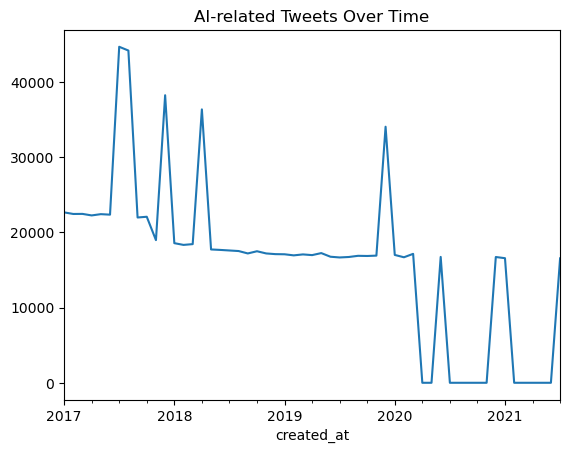

In [18]:
tweets_per_month = (
    df
    .set_index("created_at")
    .resample("M")
    .size()
)

tweets_per_month.plot(title="AI-related Tweets Over Time")
plt.show()


In [20]:
df["hashtags"].str.len().describe()

count    893076.000000
mean         43.833159
std          54.792610
min           2.000000
25%           2.000000
50%          26.000000
75%          62.000000
max         341.000000
Name: hashtags, dtype: float64

#### Suavizado rolling avrg

<Axes: title={'center': 'Smoothed Trend of AI-related Tweets (3-month moving average)'}, xlabel='created_at'>

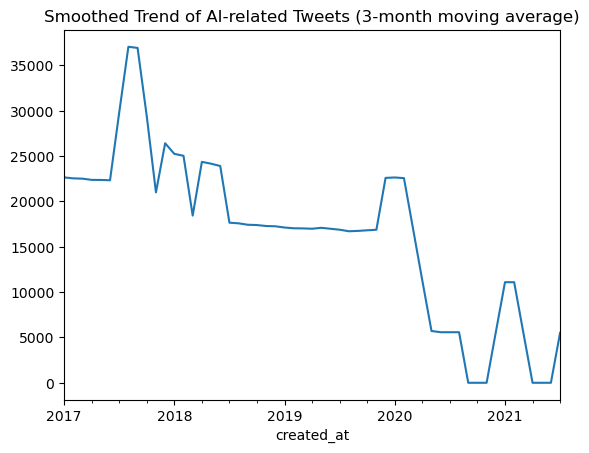

In [21]:
tweets_per_month_rolling = tweets_per_month.rolling(window=3, min_periods=1).mean()

tweets_per_month_rolling.plot(
    title="Smoothed Trend of AI-related Tweets (3-month moving average)"
)


<Axes: title={'center': 'Proportion of AI-related Tweets Over Time'}, xlabel='created_at'>

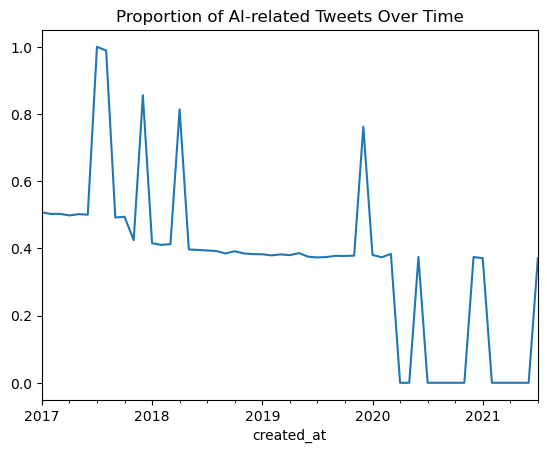

In [23]:
tweets_per_month_norm = tweets_per_month / tweets_per_month.max()

tweets_per_month_norm.plot(
    title="Proportion of AI-related Tweets Over Time"
)
